# Nave Bayes Algorithm

It is a classification algorithm which is based on conditional probability and bayes' theorem

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

In [2]:
dataset=pd.read_csv(r"C:\Users\HP\Downloads\placement-dataset.csv")
dataset.head(3)

,city,cgpa,iq,placement
0,New York,6.8,123.0,1
1,Los Angeles,5.9,106.0,0
2,Chicago,NaN,121.0,0


In [3]:
dataset=dataset.drop(columns=["city"])
dataset.head(3)

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,NaN,121.0,0


In [5]:
dataset.isnull().sum()

cgpa         8
iq           4
placement    0
dtype: int64

In [8]:
dataset["cgpa"]=dataset["cgpa"].fillna(dataset["cgpa"].mean())
dataset["iq"]=dataset["iq"].fillna(dataset["iq"].mean())

In [9]:
dataset.isnull().sum()

cgpa         0
iq           0
placement    0
dtype: int64

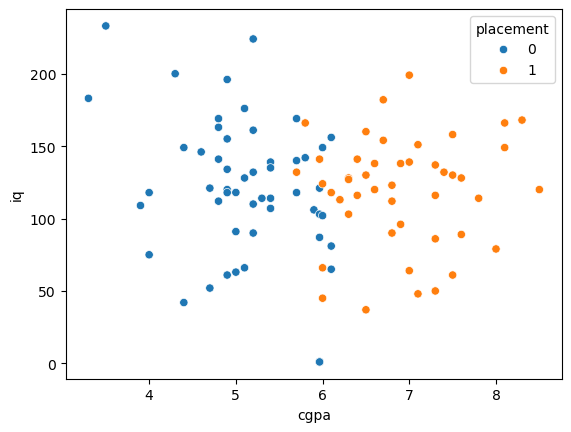

In [10]:
sns.scatterplot(x="cgpa",y="iq",data=dataset,hue="placement")
plt.show()

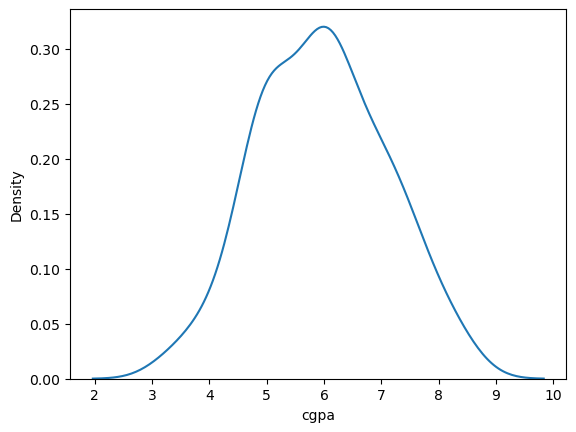

In [11]:
sns.kdeplot(data=dataset["cgpa"])
plt.show()

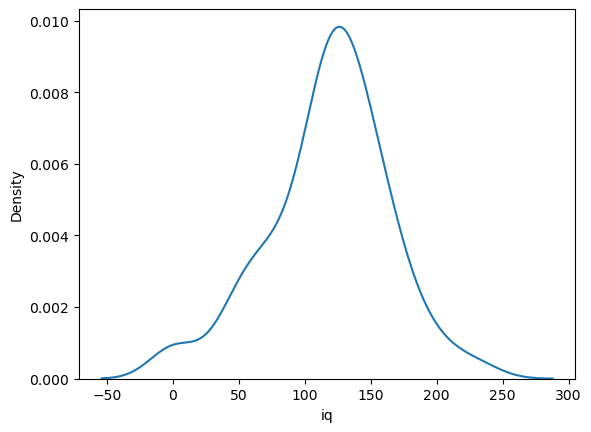

In [12]:
sns.kdeplot(data=dataset["iq"])
plt.show()

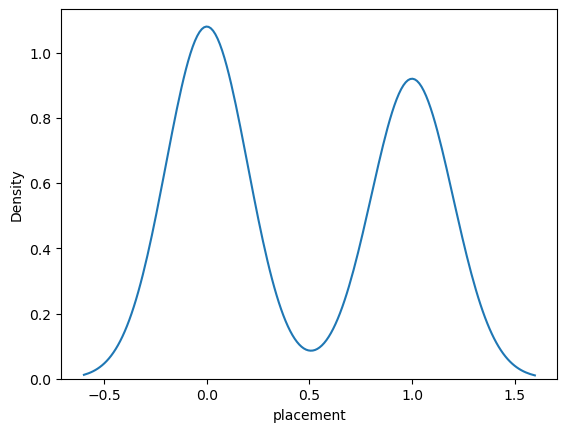

In [13]:
sns.kdeplot(data=dataset["placement"])
plt.show()

In [14]:
x=dataset.iloc[:,:-1]
y=dataset["placement"]

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [17]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB

In [18]:
gnb=GaussianNB()
gnb.fit(x_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [19]:
gnb.score(x_test,y_test)*100

85.0

In [20]:
gnb.score(x_train,y_train)*100

95.0

In [21]:
mnb=MultinomialNB()
mnb.fit(x_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [22]:
mnb.score(x_test,y_test)*100,mnb.score(x_train,y_train)*100

(70.0, 53.75)

In [23]:
bnb=BernoulliNB()
bnb.fit(x_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [24]:
bnb.score(x_test,y_test)*100,bnb.score(x_train,y_train)*100

(50.0, 55.00000000000001)

C:\Users\HP\.conda\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


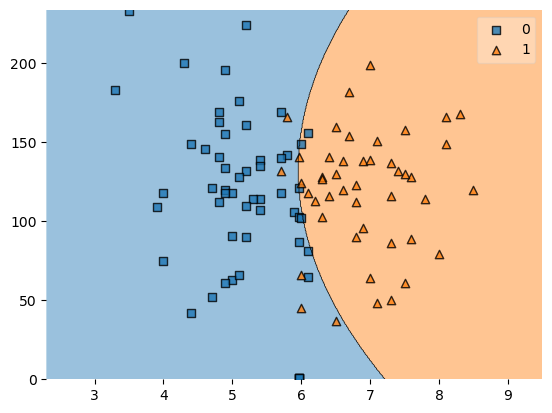

In [25]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=gnb)
plt.show()

C:\Users\HP\.conda\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


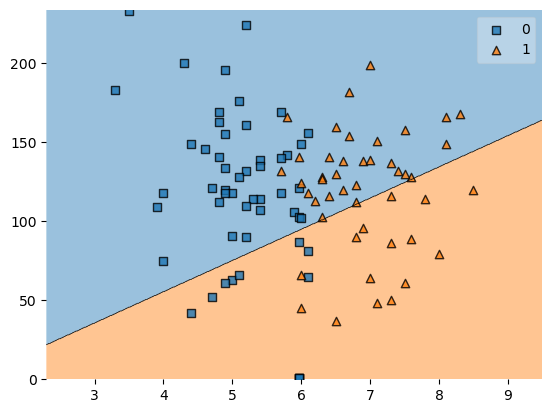

In [26]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=mnb)
plt.show()

C:\Users\HP\.conda\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(


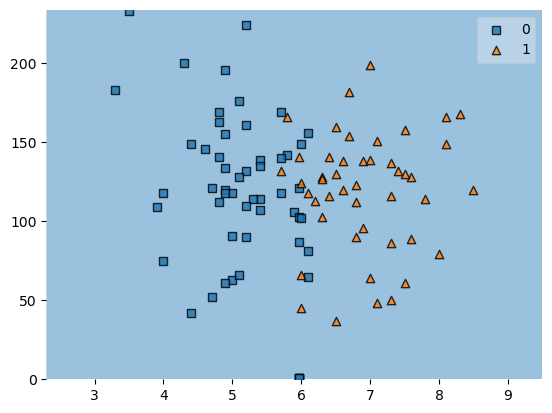

In [27]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=bnb)
plt.show()

In [29]:
gnb.predict([[6.8,123.0]]) #6.8	123.0	1

C:\Users\HP\.conda\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


array([1])